In [1]:
# Packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot
import numpy as np
import pandas as pd
import seaborn
import sys
# Open flood_tool package
sys.path.append('../..')
import flood_tool as ft

## Opening Dataset

In [2]:
# Open dataset
DF_orig = pd.read_csv("../resources/district_data.csv")
DF_orig

,postcodeDistrict,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,AB10,0.164463,0.188610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AB11,0.206145,0.236411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AB12,0.300306,0.344397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AB13,1.145815,1.314045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AB14,1.008732,1.156835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2825,YO8,0.261034,0.299359,0.149670,0.083883,0.05,0.104744,0.198599,0.227873,0.166795,0.018437
2826,ZE1,0.454124,0.520799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2827,ZE2,0.677350,0.776799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2828,ZE3,0.458550,0.525875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Calculate percentage of missing values in each column
missing = DF_orig.isnull().sum() / len(DF_orig)
missing

postcodeDistrict    0.000000
catsPerHousehold    0.000000
dogsPerHousehold    0.000000
pre_1900            0.225442
1900_1929           0.225442
1930_1945           0.225442
1945_1964           0.225442
1965_1982           0.225442
1983_1999           0.225442
2000_present        0.225442
unknown             0.225442
dtype: float64

## Plotting Data

In [4]:
# Statistics
DF_orig.describe()

,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
count,2830.000000,2830.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000
mean,0.451960,0.518317,0.197530,0.093760,0.089460,0.156591,0.188545,0.134426,0.123103,0.016940
std,0.401342,0.460267,0.137016,0.080593,0.082045,0.092562,0.093559,0.070138,0.087549,0.014736
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001038,0.000000,0.000000
25%,0.196758,0.225646,0.088863,0.041339,0.039932,0.097671,0.131608,0.089665,0.074845,0.007158
50%,0.340893,0.390943,0.177686,0.071460,0.064075,0.143455,0.178422,0.125280,0.104807,0.013366
75%,0.592085,0.679015,0.278141,0.117104,0.110842,0.195879,0.233717,0.166175,0.145219,0.023166
max,5.212126,5.977375,0.894778,0.690773,0.701673,0.902367,0.876133,0.903670,0.884430,0.222222


Text(0.5, 1.0, 'Box Plots')

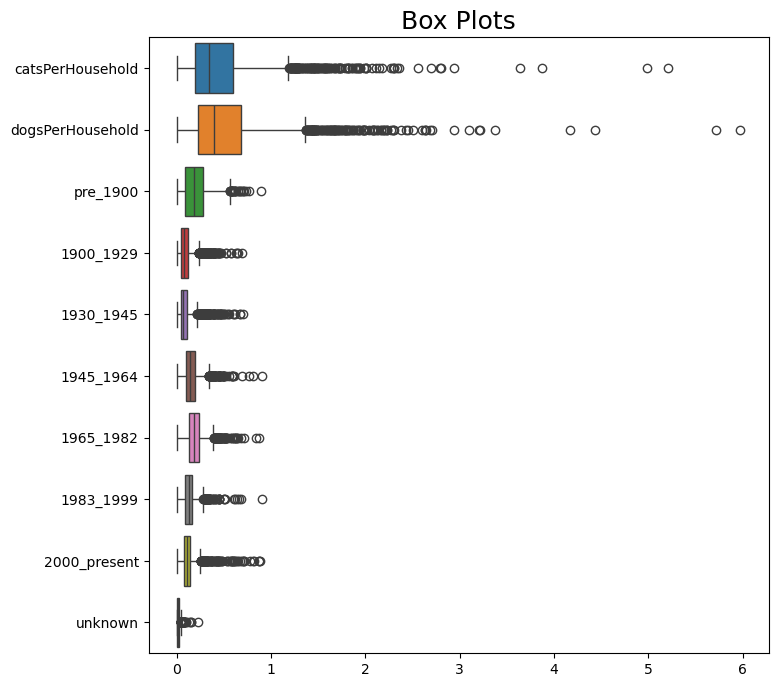

In [5]:
# Plot box plots for each numerical feature
Fig = pyplot.figure(figsize=(8,8))
seaborn.boxplot(data=DF_orig, orient='h')
pyplot.title('Box Plots', fontsize=18)

## Impute Missing Values

In [6]:
# Calculate median for each column with missing values
fraction_vars = ['pre_1900', '1900_1929', '1930_1945', '1945_1964', '1965_1982', '1983_1999', '2000_present', 'unknown']
medians = {}
for var in fraction_vars:
    medians[var] = np.nanmedian(DF_orig[var])
medians

{'pre_1900': 0.17768635294051355,
 '1900_1929': 0.0714598368319129,
 '1930_1945': 0.06407511441380614,
 '1945_1964': 0.14345525891657807,
 '1965_1982': 0.17842233924831014,
 '1983_1999': 0.1252802566429413,
 '2000_present': 0.10480743463843509,
 'unknown': 0.01336575030490995}

In [7]:
# Calculate sum of medians
medians_sum = 0
for var in medians:
    medians_sum += medians[var]
print (medians_sum)

0.8785523439374072


In [8]:
# Scale medians so that the sum of the fractions add up to 1
medians_scaled = {}
for var in medians:
    medians_scaled[var] = medians[var] / medians_sum
medians_scaled

{'pre_1900': 0.20224902268677217,
 '1900_1929': 0.08133816650201105,
 '1930_1945': 0.07293260880352417,
 '1945_1964': 0.16328595547722832,
 '1965_1982': 0.20308674887676573,
 '1983_1999': 0.142598511639583,
 '2000_present': 0.11929560641625485,
 'unknown': 0.01521337959786059}

In [9]:
# Calculate sum of scaled medians
medians_scaled_sum = 0
for var in medians:
    medians_scaled_sum += medians_scaled[var]
print (medians_scaled_sum)

0.9999999999999999


In [10]:
# Impute missing values using the scaled median
def Impute_Missing(DF_orig, medians):
    DF = DF_orig.copy()
    for var in fraction_vars:
        scaled_median = medians_scaled[var]
        DF[var] = DF_orig[var].fillna(scaled_median)
    return (DF)
DF_imputed = Impute_Missing(DF_orig, medians_scaled)
DF_imputed

,postcodeDistrict,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,AB10,0.164463,0.188610,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
1,AB11,0.206145,0.236411,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
2,AB12,0.300306,0.344397,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
3,AB13,1.145815,1.314045,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
4,AB14,1.008732,1.156835,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
...,...,...,...,...,...,...,...,...,...,...,...
2825,YO8,0.261034,0.299359,0.149670,0.083883,0.050000,0.104744,0.198599,0.227873,0.166795,0.018437
2826,ZE1,0.454124,0.520799,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
2827,ZE2,0.677350,0.776799,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213
2828,ZE3,0.458550,0.525875,0.202249,0.081338,0.072933,0.163286,0.203087,0.142599,0.119296,0.015213


In [11]:
# Verify no more missing values
missing = DF_imputed.isnull().sum() / len(DF_imputed)
missing

postcodeDistrict    0.0
catsPerHousehold    0.0
dogsPerHousehold    0.0
pre_1900            0.0
1900_1929           0.0
1930_1945           0.0
1945_1964           0.0
1965_1982           0.0
1983_1999           0.0
2000_present        0.0
unknown             0.0
dtype: float64

## Outputting Preprocessed Data

In [12]:
# Define output directory
Output_Diri = '../resources/preprocessed_data/'

In [13]:
# Output preprocessed data as new csv file
DF_imputed.to_csv(Output_Diri+'district_preprocessed.csv', index=False)